# M2 Agentic AI - 图表生成

欢迎学习 **Agentic AI** 课程！在本 **非评分实验** 以及后续实验中，你将通过代码实践视频里讲到的概念与设计模式。

可以把这些实验当作 **沙盒**：一个安全的练习环境，用来加深对课程概念的理解、建立信心，并为之后的评分作业做准备。每个实验中，请运行代码单元格，观察 agentic workflow 的实际运行方式。

在部分环节，你会被鼓励修改代码——例如调整 prompt、换用不同 LLM、或在 workflow 中加入新查询。请多实验，观察改动如何影响 workflow 的行为。

最重要的是，非评分实验让你按自己的节奏学习，同时动手实践 **Agentic AI** 的核心理念。记住——你不是一个人在学！如有问题，欢迎到
<a href="https://community.deeplearning.ai/c/course-q-a/agentic-ai/567" target="_blank">社区</a> 提问。


## 1. 简介
### 1.1. 实验概览

在本实验中，你将在一个生成数据可视化的 agentic workflow 里实现视频介绍的 **反思模式（reflection pattern）**。多模态 LLM 会审查第一版图表，找出可改进之处（图表类型、标签、配色等），然后重写绘图代码，产出更有效的可视化。

视频中 Andrew 展示了分析咖啡销售的 workflow，你将在这里用代码实现。Workflow 的步骤如下：

1. **生成初始版本（V1）：**
   用大语言模型（LLM）编写第一版绘图代码。

2. **执行代码并生成图表：**
   运行生成的代码并展示结果图表。

3. **对输出进行反思：**
   用 LLM 评估代码与图表，找出可改进之处（清晰度、准确性、设计等）。

4. **生成并执行改进版本（V2）：**
   根据反思结果改写绘图代码，渲染改进后的图表。

<img src='M2-UGL-2.png'>

### 🎯 1.2. 学习成果

完成本实验后，你将在代码中实现反思模式，并用它改进数据可视化。

## 2. 环境准备：初始化环境与客户端

本步导入 workflow 所需的核心库：

- **`re`**：Python 正则表达式模块，用于从 LLM 输出中提取代码或结构化文本。
- **`json`**：读写 JSON，用于解析 LLM 返回的结构化响应。
- **`utils`**：本实验提供的辅助模块，包含加载数据、生成图表、美化展示等工具函数。


In [1]:
# 标准库导入
import re
import json

# 本地辅助模块
import utils


### 2.1. 加载数据集

先看看咖啡销售数据，了解文件里有哪些字段。

In [2]:
# 用 utils.py 加载数据到 DataFrame
df = utils.load_and_prepare_data('coffee_sales.csv')

# 随机抽样展示
utils.print_html(df.sample(n=5), title="咖啡销售数据随机样本")


date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-05-02,09:55,card,ANON-0000-0000-0144,3.772,Cappuccino,2,5,2024
2024-10-10,06:05,card,ANON-0000-0000-0003,2.596,Americano,4,10,2024
2025-01-29,14:14,card,ANON-0000-0000-1139,2.106,Espresso,1,1,2025
2024-07-02,09:06,card,ANON-0000-0000-0019,3.772,Latte,3,7,2024
2024-10-04,09:08,card,ANON-0000-0000-0003,2.596,Americano,4,10,2024


你将基于该数据集构建 agentic workflow，生成数据可视化，以回答售货机咖啡销售相关的问题。

## 3. 构建 Pipeline

### 3.1 步骤 1 — 生成绘图代码（V1）

本步中，你让 LLM 根据用户对咖啡数据集的查询，编写生成图表的 Python 代码。数据集包含 `date`、`coffee_type`、`quantity`、`revenue` 等字段，你会把 schema 传给 LLM，让它知道有哪些数据可用。

你要问模型的问题与视频中相同：
**「Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.」**
（创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。）

LLM 的输出将是使用 **matplotlib** 的 Python 代码。代码不会直接显示图表，而是写在 `<execute_python>` 标签之间，以便后续步骤提取并执行。Module 3 会进一步介绍这些标签。


In [3]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """使用标签包裹的方式，生成 matplotlib 绘图 Python 代码。"""

    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date   (datetime64 — already parsed; use df['date'].dt.year, df['date'].dt.month, etc.)
    - time   (string, HH:MM — do NOT concatenate or combine with the date column)
    - cash_type (string: 'card' or 'cash')
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (int, 1–4 — already computed, use directly)
    - month  (int, 1–12 — already computed, use directly)
    - year   (int, e.g. 2024 — already computed, use directly)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    8. CRITICAL: 'date' is datetime64 — never use string concatenation on it.
       Filter by year/quarter using the 'year' and 'quarter' integer columns.
    
    Return ONLY the code wrapped in <execute_python> tags.
    """

    response = utils.get_response(model, prompt)
    return response

现在运行函数，查看返回结果！

In [4]:
# 生成初始代码
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model="glm-4-flash", 
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM 输出的初稿代码")


很好！你已经生成了绘图用的 Python 代码。

注意代码被包在 `<execute_python>` 标签之间。这些标签便于在 workflow 下一步自动提取并运行代码。

细节暂时不用深究——**Module 3** 会进一步讲解这些标签的用法。


### 3.2. 步骤 2 — 执行代码并生成图表

本步用正则表达式提取上一步 LLM 生成的 Python 代码（`<execute_python>` 标签内的部分），然后运行代码，产出 **第一版图表**。

流程如下：

1. **提取代码：**
   用正则匹配 `<execute_python>` 标签内的代码。

2. **执行代码：**
   在预设的全局环境中运行，其中 DataFrame `df` 已就绪，无需重新加载数据。

3. **生成图表：**
   若执行成功，会创建图表并保存为 `chart_v1.png`。

4. **在 notebook 中查看：**
   用 `utils.print_html` 内联展示保存的图表，便于审查。

完成本步后，你就有了第一版可视化（V1）——反思 workflow 的重要里程碑。



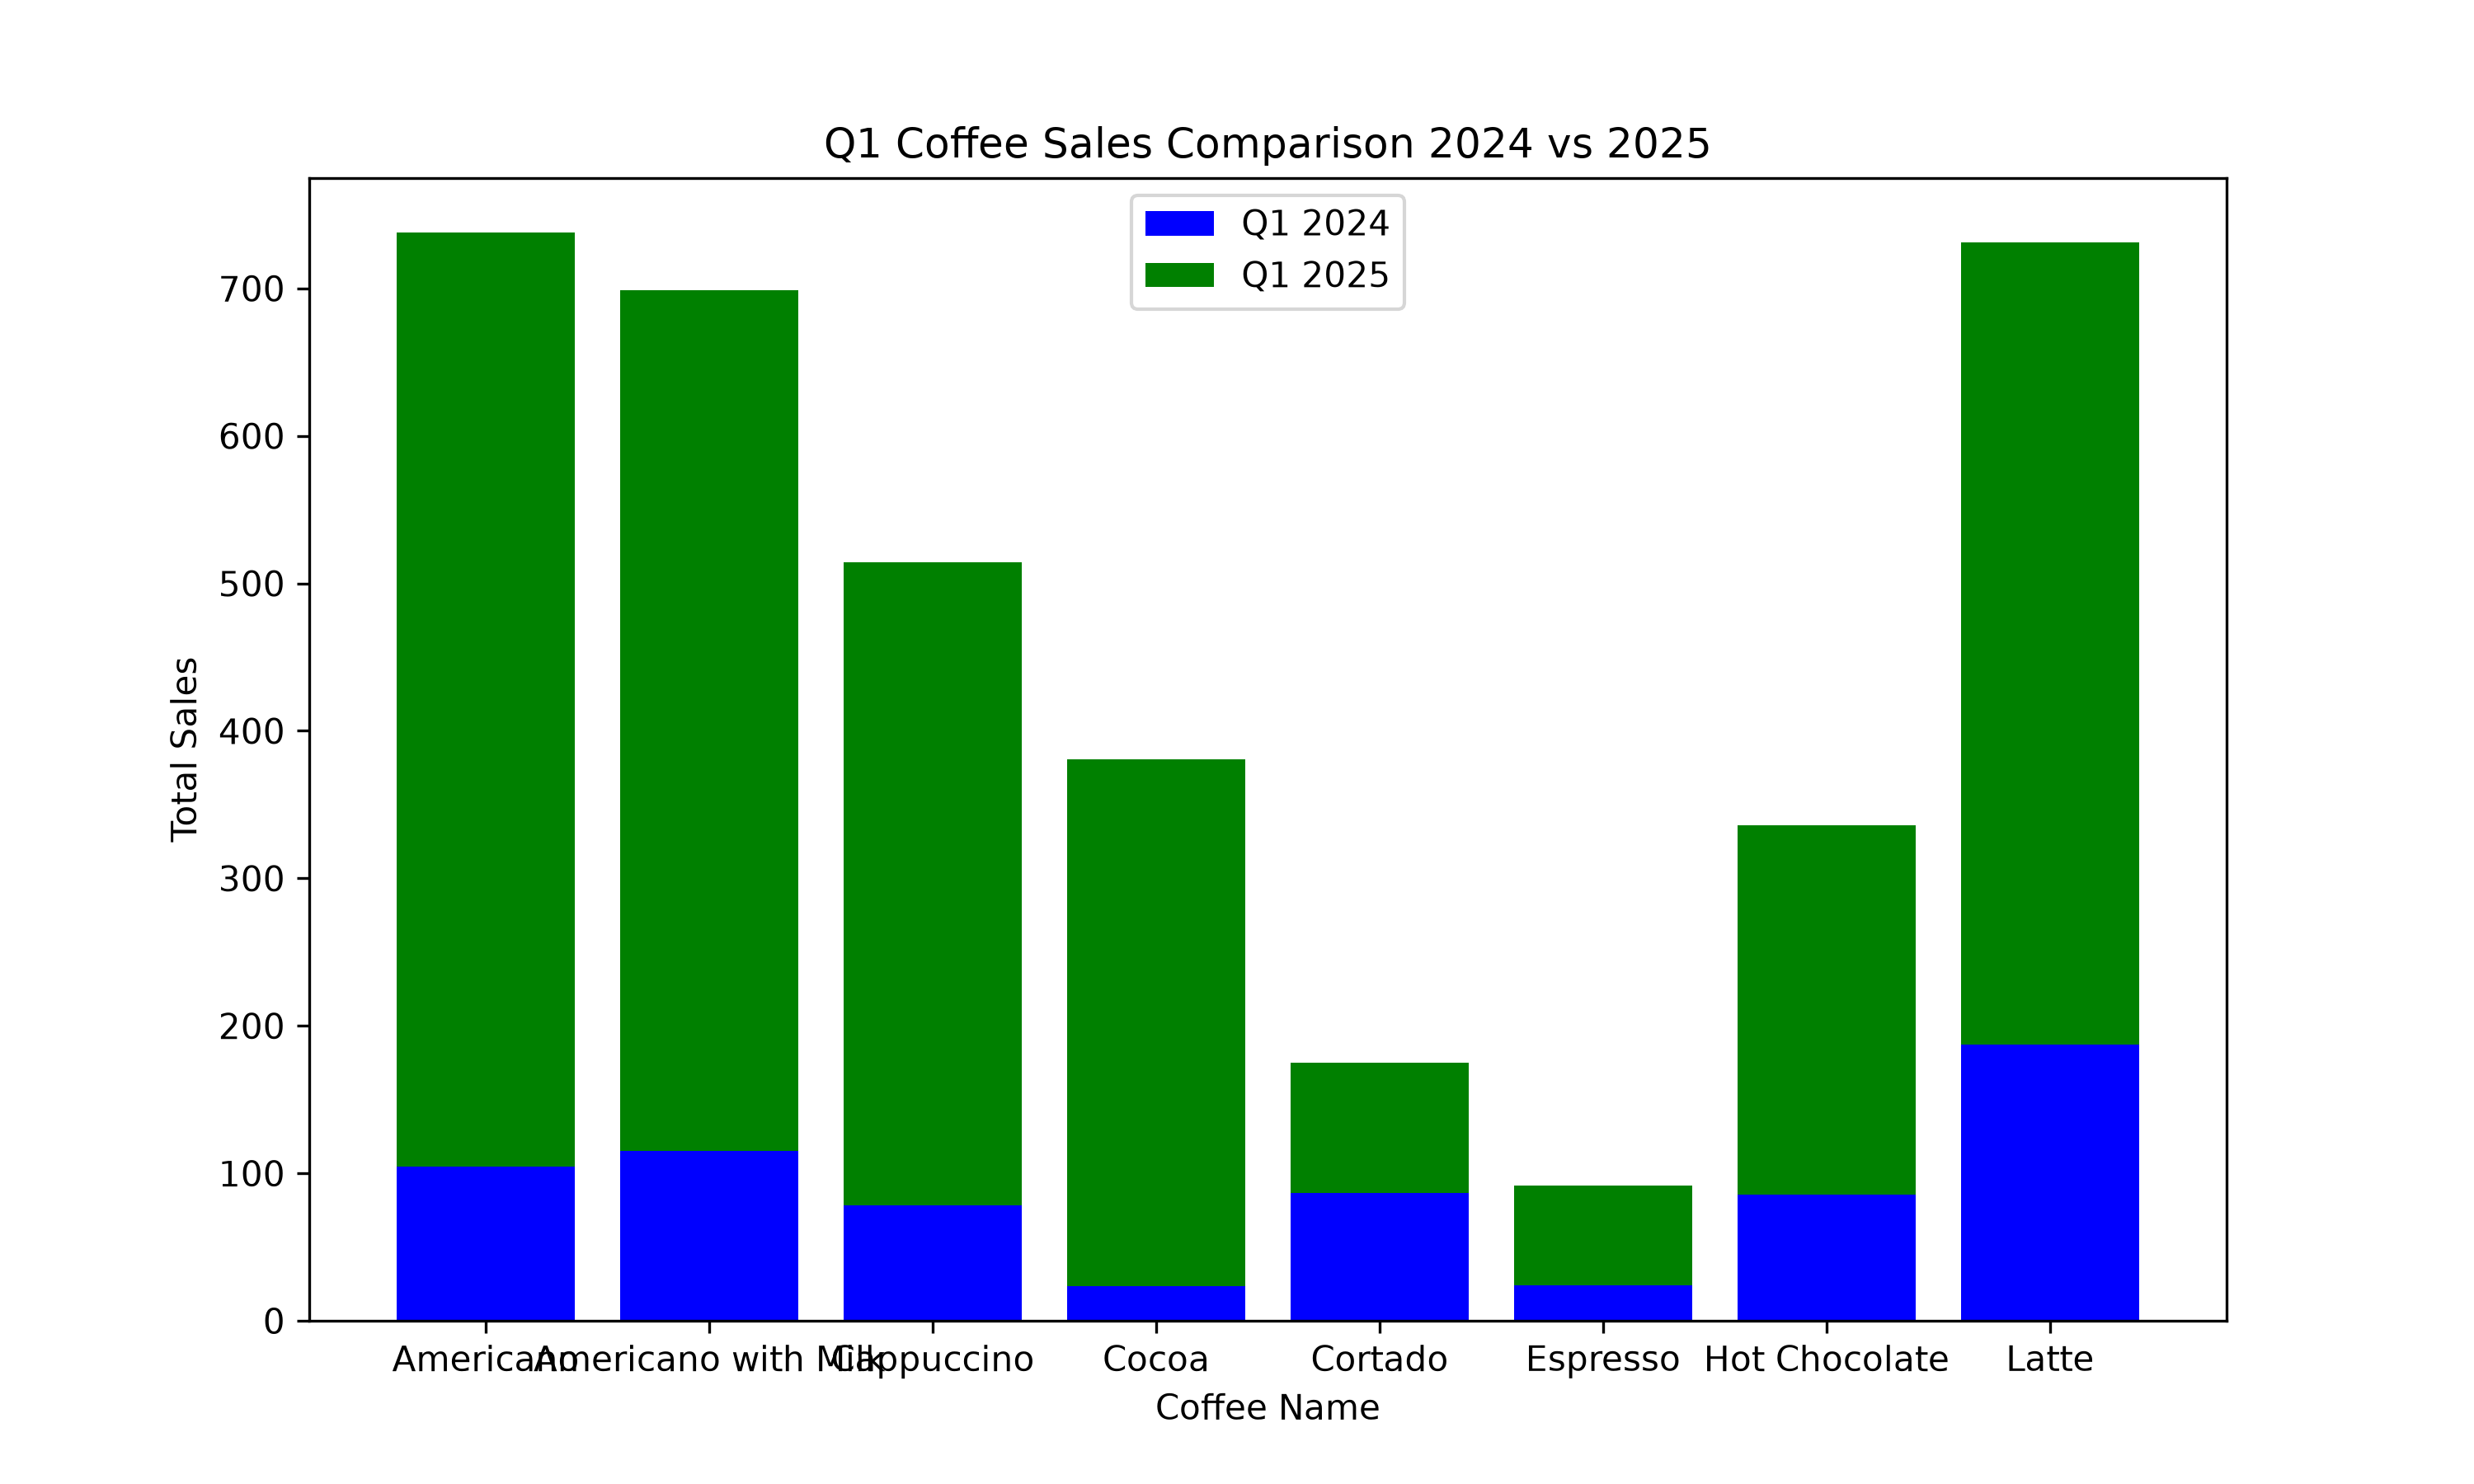

In [5]:
# 提取 <execute_python> 标签内的代码
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="待执行的提取代码")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# 若执行成功，应已生成 chart_v1.png
utils.print_html(
    content="chart_v1.png",
    title="生成的图表（V1）",
    is_image=True
)


### 3.3. 步骤 3 — 对输出进行反思

目标是模拟人类审查图表初稿：找出优点、不足与改进空间。

流程如下：

**1. 把图表提供给 LLM：**
将生成的 `chart_v1.png` 发给 LLM，让它「看到」可视化结果。

**2. 视觉分析：**
LLM 审查清晰度、标签、准确性、可读性等。

**3. 生成反馈：**
LLM 提出改进建议，例如修正轴标签、调整图表类型、优化配色、补充图例等。

由此形成智能反馈闭环：图表不只生成一次，还会被主动批评——为更强的第二版（V2）做准备。


In [6]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,  
) -> tuple[str, str]:
    """
    对照指令审查图表图片与原始代码，返回改进后的 matplotlib 代码。
    返回 (feedback, refined_code_with_tags)。
    支持 OpenAI、Anthropic（Claude）及智谱等 OpenAI 兼容视觉模型。
    """
    media_type, b64 = utils.encode_image_b64(chart_path)
    

    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.
    
    IMPORTANT: The 'date' column is already a pandas datetime64 type.
    - Do NOT concatenate 'date' with 'time' using string operations.
    - To filter by year/quarter, use: df[df['year'] == 2024] or df['date'].dt.year == 2024
    - The 'quarter' and 'year' columns already exist as integers; use them directly.

    Schema (columns available in df):
    - date   (datetime64 — already parsed; use df['date'].dt.year, etc.)
    - time   (string, HH:MM — do NOT concatenate with date)
    - cash_type (string: 'card' or 'cash')
    - card   (string)
    - price  (float)
    - coffee_name (string)
    - quarter (int, 1–4)
    - month  (int, 1–12)
    - year   (int)
    
    CRITICAL TYPE RULE: 'date' is already datetime64.
    - NEVER do: df['date'] + ' ' + df['time']  ← this will crash
    - ALWAYS filter by year/quarter using the integer columns: df[df['year'] == 2024]

    Instruction:
    {instruction}
    """


    # 若模型名含 Claude 或 Anthropic，走对应辅助函数
    lower = model_name.lower()
    if "claude" in lower or "anthropic" in lower:
        # 使用合并所有文本块的辅助函数
        content = utils.image_anthropic_call(model_name, prompt, media_type, b64)
    else:
        content = utils.image_openai_call(model_name, prompt, media_type, b64)

    # --- 仅解析第一行 JSON（feedback）---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line)
    except Exception as e:
        # 回退：尝试匹配第一个 {...}
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}", "refined_code": ""}
        else:
            obj = {"feedback": f"Failed to find JSON: {e}", "refined_code": ""}

    # --- 从 <execute_python> 标签提取改进代码 ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code

注意，模型被要求以 **JSON 格式** 返回响应：

- JSON 是轻量级结构化格式（键值对），便于程序解析 LLM 输出。
- 这里需要两个字段：
  - **`feedback`**：对当前图表的简短点评。
  - **`refined_code`**：改进后的 Python 代码，包在 `<execute_python>` 标签中。

Prompt 中还包含 **约束条件**，例如只用 matplotlib、保存到指定路径、末尾调用 `plt.close()` 等，帮助模型生成一致、可运行的代码。没有这些约束，输出可能差异过大或包含多余格式。


### 3.4 步骤 4 — 生成并执行改进版本（V2）

最后一步：生成并运行改进版图表（V2）。
运行单元格后，你会看到 **LLM 的反思文字**（说明需要改进什么）**以及新生成的代码**。随后执行新代码，产出更新后的图表。


In [7]:
# 生成反馈与反思后的代码
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",            
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model_name="glm-4v-plus",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,   # 传入原始代码作为上下文
)

utils.print_html(feedback, title="对 V1 图表的反馈")
utils.print_html(code_v2, title="重新生成的代码（V2）")


现在执行反思步骤返回的改进代码。`<execute_python>` 标签内的代码会被提取，在数据集上运行，生成更新后的图表。

若执行成功，下方会显示新图片（`chart_v2.png`），即 **改进版图表（V2）**。



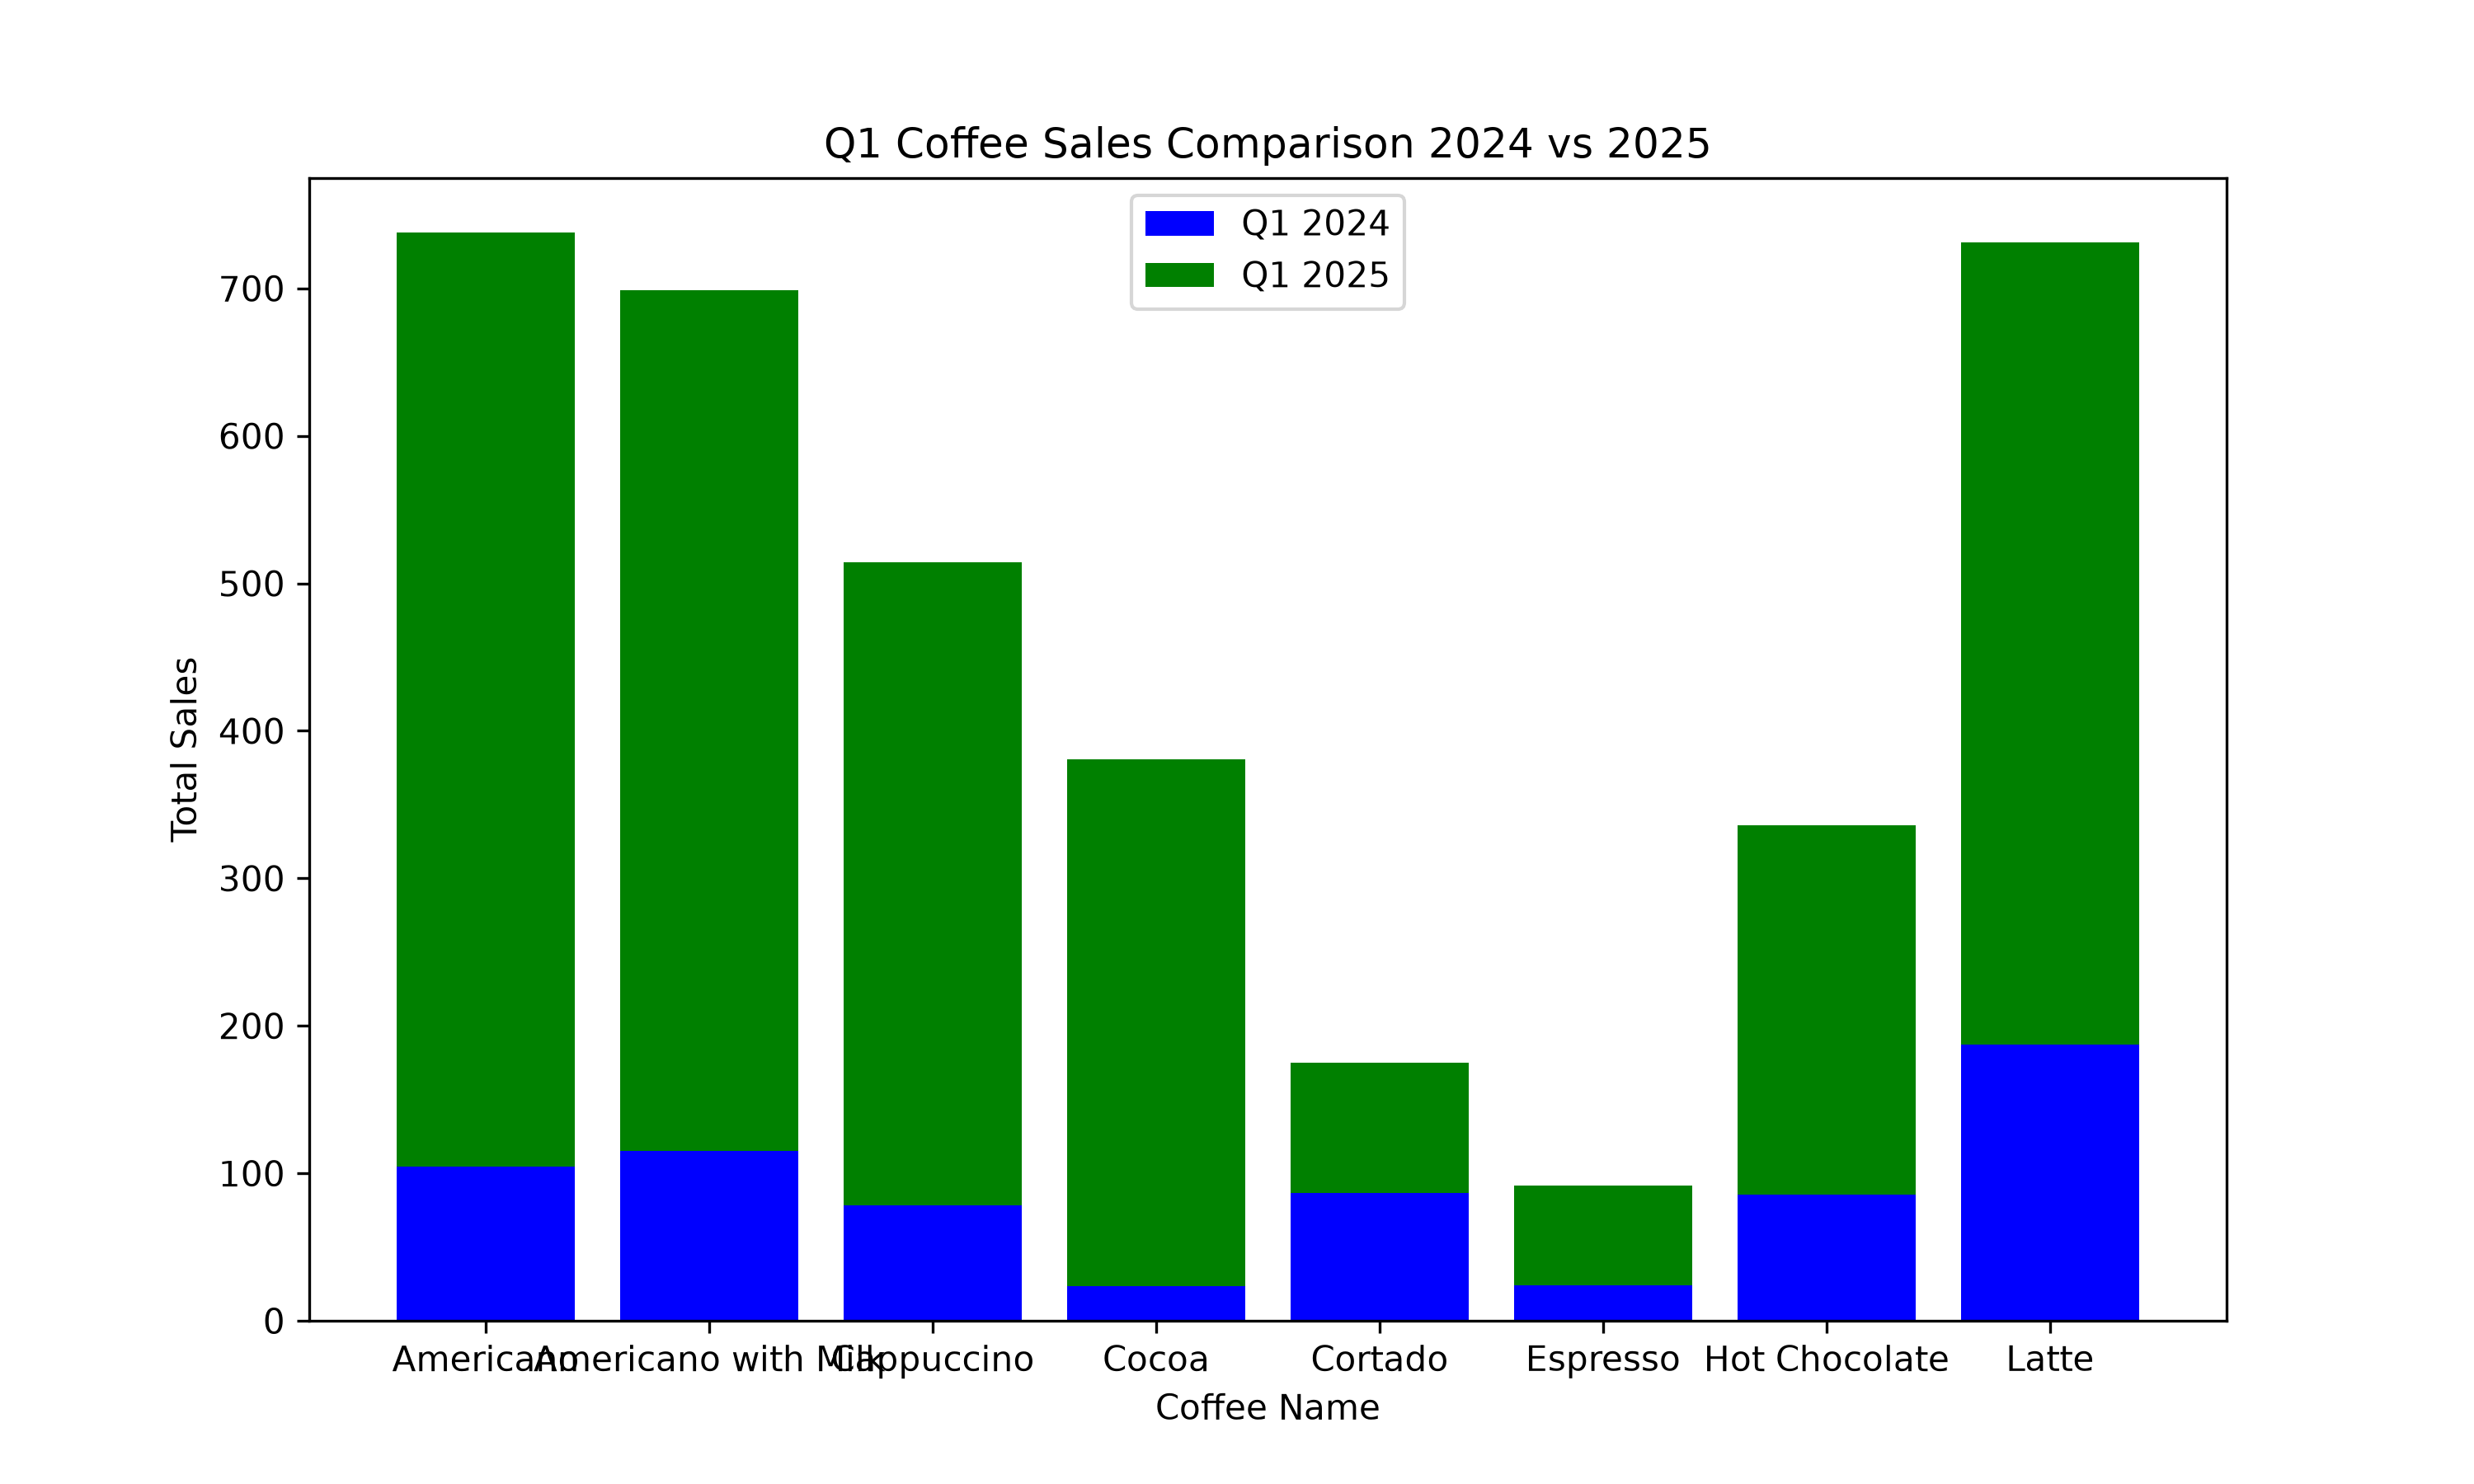

In [8]:
# 提取 <execute_python> 标签内的代码
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# 若执行成功，应已生成 chart_v2.png
utils.print_html(
    content="chart_v2.png",
    title="改进版图表（V2）",
    is_image=True
)


### 4. 整合 — 构建端到端 Workflow

现在把各组件封装成一个 Agent 可从头到尾自动运行的 workflow。

`run_workflow` 函数串联你之前实现的步骤：

1) **加载并准备数据** — `utils.load_and_prepare_data(...)`。
2) **生成 V1 代码** — `generate_chart_code(...)`，返回初稿 matplotlib 代码（包在 `<execute_python>` 标签中）。
3) **立即执行 V1** — 提取标签内代码并运行，生成第一张图表。
4) **反思并改进** — `reflect_on_image_and_regenerate(...)` 对照指令审查 V1 图片（及原始代码），返回 **feedback** 与 **改进代码（V2）**。
5) **立即执行 V2** — 提取并执行改进代码，生成更好的图表。

### Workflow 参数说明
- **`dataset_path`**：输入 CSV 路径。
- **`user_instructions`**：图表需求（例如对比 Q1 咖啡销售）。
- **`generation_model`**：初稿代码生成模型。
- **`reflection_model`**：基于图像反思与代码改进的模型。
- **`image_basename`**：图表文件名前缀（如 `chart_v1.png`、`chart_v2.png`）。

> 说明：图表执行步骤在代码生成/改进后 **硬编码** 立即运行，与视频 workflow 一致，确保你在继续之前能看到每一版输出。


In [9]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,   
    image_basename: str = "chart",
):
    """
    端到端 pipeline：
      1) 加载数据集
      2) 生成 V1 代码
      3) 执行 V1 → 产出 chart_v1.png
      4) 对 V1（图片 + 原始代码）反思 → feedback + 改进代码
      5) 执行 V2 → 产出 chart_v2.png

    返回包含所有产物（代码、反馈、图片路径）的字典。
    """
    # 0) 加载数据；utils 负责解析与衍生字段（year/quarter 等）
    df = utils.load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="数据集随机样本")

    # 图表保存路径
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    # 1) 生成代码（V1）
    utils.print_html("步骤 1：生成图表代码（V1）… 📈")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM 输出的初稿代码（V1）")

    # 2) 执行 V1（硬编码：提取 <execute_python> 块并立即运行）
    utils.print_html("步骤 2：执行图表代码（V1）… 💻")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)
    utils.print_html(out_v1, is_image=True, title="生成的图表（V1）")

    # 3) 对 V1（图片 + 原始代码）反思，获取 feedback 与改进代码（V2）
    utils.print_html("步骤 3：反思 V1（图片 + 代码）并生成改进… 🔁")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,  # 传入原始代码作为上下文
    )
    utils.print_html(feedback, title="对 V1 的反思反馈")
    utils.print_html(code_v2, title="LLM 输出的改进代码（V2）")

    # 4) 执行 V2（硬编码：提取 <execute_python> 块并立即运行）
    utils.print_html("步骤 4：执行改进后的图表代码（V2）… 🖼️")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if match:
        reflected_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(reflected_code, exec_globals)
    utils.print_html(out_v2, is_image=True, title="改进版图表（V2）")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }


### 4.2. 运行 Workflow

现在用视频中的示例，跑通完整 workflow。

- **使用的指令：**
  「Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.」

运行后将会：
1. 生成初稿绘图代码。
2. 立即执行，产出第一版图表（V1）。
3. 对图表与原始代码反思，产出 feedback 与改进代码（V2）。
4. 执行改进代码，生成更好的图表（V2）。

### 自定义与实验

试完示例后，可修改 `user_instructions` 换成自己的图表需求。
同时调整 `image_basename`，让每次运行保存到新文件名，避免覆盖旧图。

### 选择模型

生成与反思可使用不同模型，例如：
- 初稿代码：`glm-4-flash`（快）或 `glm-4-plus`（更强）。
- 看图反思：`glm-4v-plus` 或 `glm-4v-flash`（视觉模型）。

这样可以在速度与质量之间做权衡。

👉 **行动建议：** 先用视频示例指令运行 workflow，再换成自己的 prompt，观察 Agent 如何适应。


In [10]:
# 在此修改你的参数
user_instructions="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv." # 在此填写你的图表指令
generation_model="glm-4-flash"
reflection_model="glm-4v-plus"
image_basename="drink_sales"

# 运行完整 agentic workflow
_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)


date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-02-28,15:28,card,ANON-0000-0000-1190,2.596,Americano,1,2,2025
2025-03-15,11:43,card,ANON-0000-0000-1167,2.596,Americano,1,3,2025
2024-10-28,15:38,card,ANON-0000-0000-0695,3.086,Americano with Milk,4,10,2024
2025-02-26,11:21,card,ANON-0000-0000-1191,3.576,Latte,1,2,2025
2024-04-19,16:24,card,ANON-0000-0000-0009,3.380,Americano with Milk,2,4,2024


KeyError: 'quarter'

## 5. 总结

本实验中，**你** 练习了用反思改进图表输出，学会了：

* 生成初始图表（V1）。
* 批评并改进为更好版本（V2）。
* 用不同模型自动化完整 workflow。

核心思想：反思帮助 **你** 创建更清晰、准确、有效的可视化。


<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b; font-family:system-ui,-apple-system,Segoe UI,Roboto,Ubuntu,Cantarell,Noto Sans,sans-serif;">

🎉 <strong>恭喜！</strong>

你已完成 **Agentic 图表生成 Workflow** 实验。
过程中，**你** 练习了生成图表、反思质量，并改进为更清晰有效的可视化。

掌握这些技能后，**你** 已能设计自动创建数据可视化的 Agent pipeline，同时保持准确、可解释与精美。🌟

</div>
